In [7]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, AnyMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

True

In [8]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.0-flash")

# Binding a tool

In [9]:
def multiply(a: float, b: float) -> float:
    return a * b


In [10]:
binded_llm = llm.bind_tools([multiply])

In [17]:
response = binded_llm.invoke([HumanMessage(content = "multiply 2 and 3", name = "faizan")])

In [22]:
response.additional_kwargs

{'function_call': {'name': 'multiply', 'arguments': '{"a": 2.0, "b": 3.0}'}}

### Message State (pre-build in langgraph) as well as custom build

In [ ]:
# from typing import TypedDict, Annotated
# from langgraph.graph.message import add_messages

# # custom class
# class MesssageState(TypedDict):
#     message: Annotated[list[AnyMessage], add_messages]

# # pre-build class
# from langgraph.graph import MessageGraph
# class State(MessageGraph):
#     pass

In [68]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# from langgraph.graph import MessagesState
# class MessageState(MessagesState):
#     pass

In [69]:
def llm_call(state: MessageState):
    return {"messages": llm.invoke(state['messages'])}

In [70]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(MessageState)

graph.add_node("llm_call", llm_call)

graph.add_edge(START, "llm_call")
graph.add_edge("llm_call",END)

wf = graph.compile()

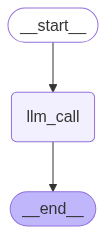

In [71]:
wf

In [72]:
final_state = wf.invoke({"messages": HumanMessage(content = "Hi Who are you?")})

In [67]:
final_state

{'messages': [HumanMessage(content='Hi Who are you?', additional_kwargs={}, response_metadata={}, id='88173fa0-fb3c-478f-8b52-9a45c0002e1f'),
  AIMessage(content='I am a large language model, trained by Google.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--e2d5e986-2e84-4739-be74-09b951bfd4a7-0', usage_metadata={'input_tokens': 5, 'output_tokens': 12, 'total_tokens': 17, 'input_token_details': {'cache_read': 0}})]}